How many of the brightest stars do you want to select?  4


C:\Users\Observatory\AppData\Local\Programs\Python\Python312\Lib\site-packages\photutils\detection\daofinder.py:594: RuntimeWarning: invalid value encountered in multiply
  data_dkern_dx_sum = np.sum(data_sum_1d * dkern_dx * wt, axis=1)
C:\Users\Observatory\AppData\Local\Programs\Python\Python312\Lib\site-packages\photutils\detection\daofinder.py:595: RuntimeWarning: invalid value encountered in multiply
  data_dx_sum = np.sum(data_sum_1d * dxx * wt, axis=1)
C:\Users\Observatory\AppData\Local\Programs\Python\Python312\Lib\site-packages\photutils\detection\daofinder.py:599: RuntimeWarning: invalid value encountered in subtract
  hx_numer = data_kern_sum - (data_sum * kern_sum) / wt_sum
C:\Users\Observatory\AppData\Local\Programs\Python\Python312\Lib\site-packages\photutils\detection\daofinder.py:594: RuntimeWarning: invalid value encountered in multiply
  data_dkern_dx_sum = np.sum(data_sum_1d * dkern_dx * wt, axis=1)
C:\Users\Observatory\AppData\Local\Programs\Python\Python312\Lib\site


Filtered star table (Top 4 brightest stars):

 id     xcentroid          ycentroid          sharpness      ...        flux                mag              daofind_mag     
--- ------------------ ------------------ ------------------ ... ------------------ ------------------- ---------------------
100  2145.771862017233 1997.4417460617587 0.4517966472233487 ...  14803.05529046011 -10.425878403157167   -1.2534073480824355
 63 3775.4593983918517 1678.9255083959013 0.7095883585912126 ...  3316.653944598159  -8.801750400390723 -0.030592576071872577
 33 1590.5781826208847  968.0443158001934 0.9061622193579376 ... 1425.0745324138404  -7.884593947123739  -0.06403973719098244
  5 1509.9785840155246  97.74095990112225 0.4585014392165233 ...  764.0811304041912  -7.207848686413647    -2.716844996190299


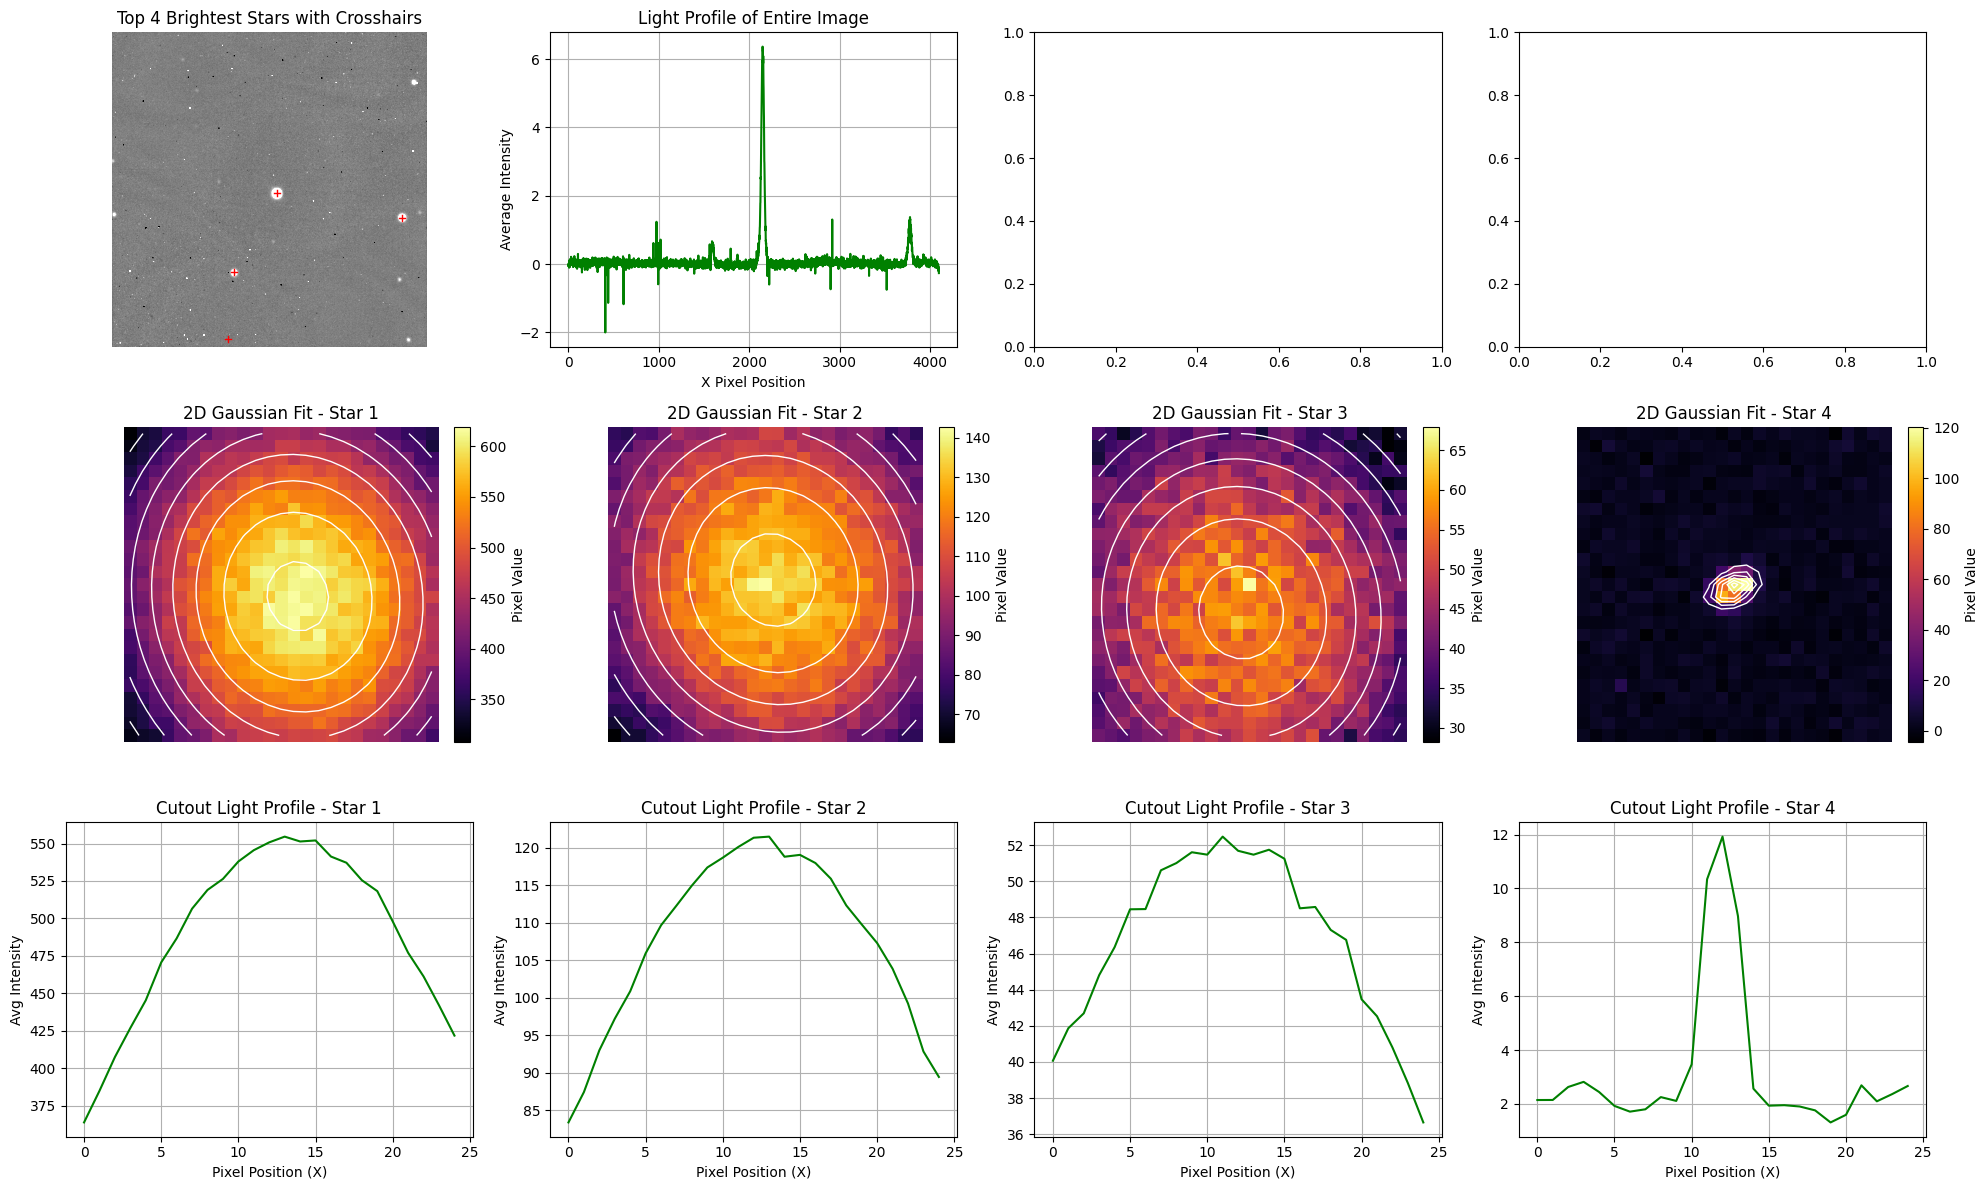

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import mad_std, sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.table import Table
from astropy.modeling import models, fitting
from astropy.nddata import Cutout2D

# === Load FITS image ===
filename = "C:\\Users\\Observatory\\Exo\\Data\\HAT-P32b-15Oct2024-low\\calibrated\\HAT-9-32b-g_2024_10_15_exp00.00.30.000_1x1_Low_1_calibrated_darkandflat.fits"
hdul = fits.open(filename)
image_data = hdul[0].data
hdul.close()

# === Ask user how many bright stars to select ===
try:
    N = int(input("How many of the brightest stars do you want to select? "))
except ValueError:
    print("Invalid input. Defaulting to 4 brightest stars.")
    N = 4

# === Star detection ===
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5. * bkg_sigma)
sources = daofind(image_data)

# === Remove close duplicates ===
def remove_close_sources(sources, min_sep=5.0):
    sources = sources.copy()
    sources.sort('flux')
    sources.reverse()
    keep = []
    for src in sources:
        x, y = src['xcentroid'], src['ycentroid']
        if not any(np.hypot(x - k['xcentroid'], y - k['ycentroid']) < min_sep for k in keep):
            keep.append(src)
    return Table(rows=keep, names=sources.colnames)

filtered_sources = remove_close_sources(sources, min_sep=80)

# === Select top N brightest stars ===
top_sources = filtered_sources[:N]

# === Show cleaned table ===
print(f"\nFiltered star table (Top {N} brightest stars):\n")
print(top_sources)

# === Plotting Setup ===
fig, axs = plt.subplots(3, max(N, 2), figsize=(5 * max(N, 2), 12))

# --- Row 1, Col 1: Main image with crosshairs ---
axs[0, 0].imshow(image_data, cmap='gray',
                 vmin=np.percentile(image_data, 5),
                 vmax=np.percentile(image_data, 95),
                 origin='lower')
axs[0, 0].set_title(f"Top {N} Brightest Stars with Crosshairs")
axs[0, 0].axis('off')

# Add red crosshairs
crosshair_size = 40
for star in top_sources:
    x, y = star['xcentroid'], star['ycentroid']
    axs[0, 0].plot([x - crosshair_size, x + crosshair_size], [y, y], 'r-', linewidth=1)
    axs[0, 0].plot([x, x], [y - crosshair_size, y + crosshair_size], 'r-', linewidth=1)

# --- Row 1, Col 2: Light profile of entire image ---
mean, median, std = sigma_clipped_stats(image_data, sigma=3.0)
light_profile = np.mean(image_data - median, axis=0)

axs[0, 1].plot(light_profile, 'g-')
axs[0, 1].set_title("Light Profile of Entire Image")
axs[0, 1].set_xlabel("X Pixel Position")
axs[0, 1].set_ylabel("Average Intensity")
axs[0, 1].grid()

# --- For each star: cutout with Gaussian fit and light profile ---
for i, star in enumerate(top_sources):
    x, y = star['xcentroid'], star['ycentroid']
    cutout_size = 25
    cutout = Cutout2D(image_data, (x, y), (cutout_size, cutout_size), mode='trim')
    cut_data = cutout.data

    # Fit 2D Gaussian
    y_grid, x_grid = np.mgrid[:cut_data.shape[0], :cut_data.shape[1]]
    g_init = models.Gaussian2D(amplitude=cut_data.max(),
                                x_mean=cut_data.shape[1] / 2,
                                y_mean=cut_data.shape[0] / 2)
    fit_g = fitting.LevMarLSQFitter()
    g_fit = fit_g(g_init, x_grid, y_grid, cut_data)

    # --- Row 2: Gaussian Fit cutout ---
    ax_cut = axs[1, i]
    im = ax_cut.imshow(cut_data, cmap='inferno', origin='lower')
    ax_cut.contour(g_fit(x_grid, y_grid), colors='white', linewidths=1)
    ax_cut.set_title(f"2D Gaussian Fit - Star {i + 1}")
    ax_cut.axis('off')
    fig.colorbar(im, ax=ax_cut, fraction=0.046, pad=0.04, label="Pixel Value")

    # --- Row 3: Light profile of cutout ---
    light_profile_cutout = np.mean(cut_data, axis=0)
    ax_prof = axs[2, i]
    ax_prof.plot(light_profile_cutout, 'g-')
    ax_prof.set_xlabel('Pixel Position (X)')
    ax_prof.set_ylabel('Avg Intensity')
    ax_prof.set_title(f'Cutout Light Profile - Star {i + 1}')
    ax_prof.grid()

# Hide unused subplots (if N < max in row)
for r in range(3):
    for c in range(N, max(N, 2)):
        axs[r, c].axis('off')

plt.tight_layout()
plt.show()
